<a href="https://colab.research.google.com/github/CamilaTovarm/banking-customer-churn-prediction/blob/main/ProyectoNCK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Proyecto Final NCK***







Maria Camila Tovar Acosta
Karen Garcia Velasquez
Leidy Natalia Méndez Rodríguez







Mineria de Datos

Docente, Fredy Leonardo Prieto Sánchez







Universidad de Cundinamarca, Extensión Chía

Programa de Ingeniería de Sistemas y Computación

Facultad de Ingeniería

2025

In [ ]:
  !pip install --upgrade google-cloud-bigquery google-cloud-storage pandas pyarrow db-dtypes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 10.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: google-cloud-storage
    Found existing installation: google-cloud-storage 2.19.0
    Uninstalling google-cloud-storage-2.19.0:
      Successfully uninstalled google-cloud-storage-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependen

In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
import numpy as np
from datetime import datetime, timedelta


# Configuración de conexión
key_path = "/content/nck-bank-351731acbfb0.json"

credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

print("Conectado al proyecto:", credentials.project_id)

# ---------------------------------------------------------------------------
# Extracción desde BigQuery
dataset_id = "Cliente_Transaccion"
tabla_clientes = "BankTurnover"
tabla_transacciones = "Transaccion"

query_clientes = f"SELECT * FROM `{credentials.project_id}.{dataset_id}.{tabla_clientes}`"
query_transacciones = f"SELECT * FROM `{credentials.project_id}.{dataset_id}.{tabla_transacciones}`"

df_clientes = client.query(query_clientes).to_dataframe()
df_transacciones = client.query(query_transacciones).to_dataframe()

print("Datos cargados correctamente:")
print(f"- Clientes: {df_clientes.shape[0]} registros")
print(f"- Transacciones: {df_transacciones.shape[0]} registros")

# ---------------------------------------------------------------------------
# Limpieza y normalización
df_clientes.columns = df_clientes.columns.str.strip()
df_transacciones.columns = df_transacciones.columns.str.strip()

df_clientes.rename(columns={"CustomerId": "customer_id"}, inplace=True)
df_transacciones.rename(columns={"Customer ID": "customer_id"}, inplace=True)

df_clientes.drop_duplicates(subset=["customer_id"], inplace=True)
df_transacciones.drop_duplicates(inplace=True)

# Conversión de columnas con fecha en transacciones
for col in df_transacciones.columns:
    if "date" in col.lower() or "fecha" in col.lower():
        df_transacciones[col] = pd.to_datetime(df_transacciones[col], errors="coerce")

# ---------------------------------------------------------------------------
# Integración limpia
cols_comunes = set(df_clientes.columns).intersection(set(df_transacciones.columns)) - {"customer_id"}
if cols_comunes:
    print("\nColumnas duplicadas detectadas (eliminadas del segundo dataset):", cols_comunes)
    df_transacciones.drop(columns=list(cols_comunes), inplace=True)

df_final = pd.merge(df_clientes, df_transacciones, on="customer_id", how="left")
df_final.dropna(axis=1, how="all", inplace=True)

# ---------------------------------------------------------------------------
# Enriquecimiento de datos
df_final["tipo_cliente"] = np.random.choice(
    ["Empresarial", "Personal Premium", "Personal Estándar"],
    size=len(df_final)
)

# ---------------------------------------------------------------------------
#  Generación coherente de fechas (con horas)
hoy = pd.Timestamp.now()
inicio_periodo = hoy - pd.DateOffset(years=10)

fechas_registro = []
fechas_actividad = []

for i, row in df_final.iterrows():
    fecha_reg = inicio_periodo + pd.Timedelta(days=np.random.randint(0, 3650))
    hora_reg = timedelta(hours=np.random.randint(0, 24), minutes=np.random.randint(0, 60))
    fecha_reg = fecha_reg + hora_reg

    fecha_trans = None
    for col in df_transacciones.columns:
        if "fecha" in col.lower():
            fecha_trans = df_transacciones.loc[df_transacciones["customer_id"] == row["customer_id"], col].max()
            break

    if pd.notnull(fecha_trans):
        year_range = pd.Timestamp(fecha_trans).year
        fecha_act = pd.Timestamp(fecha_trans) + pd.Timedelta(days=np.random.randint(0, 180))
    else:
        fecha_act = fecha_reg + pd.Timedelta(days=np.random.randint(30, 1825))

    if fecha_act > hoy:
        fecha_act = hoy - pd.Timedelta(days=np.random.randint(1, 30))
    hora_act = timedelta(hours=np.random.randint(0, 24), minutes=np.random.randint(0, 60))
    fecha_act = fecha_act + hora_act

    fechas_registro.append(fecha_reg)
    fechas_actividad.append(fecha_act)

df_final["fecha_registro"] = fechas_registro
df_final["fecha_ultima_actividad"] = fechas_actividad

# ---------------------------------------------------------------------------
# Calcular antigüedad
df_final["antiguedad_anios"] = ((hoy - df_final["fecha_registro"]).dt.days / 365).round(2)

# ---------------------------------------------------------------------------
# Vista previa de los resultados
print("\nVista previa de datos enriquecidos con fechas coherentes:")
print(df_final[["customer_id", "tipo_cliente", "fecha_registro", "fecha_ultima_actividad", "antiguedad_anios"]].head(10))

print(f"\nTotal de registros combinados: {len(df_final)}")

# ---------------------------------------------------------------------------
# Cargar a BigQuery
df_upload = df_final.drop(columns=["antiguedad_anios"])

table_id = f"{credentials.project_id}.{dataset_id}.TablaFinal"

job = client.load_table_from_dataframe(df_upload, table_id)
job.result()

print(f"\n Tabla 'TablaFinal' creada y cargada correctamente en BigQuery.")

Conectado al proyecto: nck-bank
Datos cargados correctamente:
- Clientes: 10000 registros
- Transacciones: 50000 registros

Columnas duplicadas detectadas (eliminadas del segundo dataset): {'Gender', 'Surname'}

Vista previa de datos enriquecidos con fechas coherentes:
   customer_id       tipo_cliente             fecha_registro  \
0     15647091   Personal Premium 2016-04-01 02:03:39.526958   
1     15713826  Personal Estándar 2020-11-01 00:40:39.526958   
2     15633840   Personal Premium 2017-02-11 01:26:39.526958   
3     15769915        Empresarial 2016-10-09 19:37:39.526958   
4     15652674        Empresarial 2024-01-31 08:44:39.526958   
5     15700864  Personal Estándar 2016-05-17 23:18:39.526958   
6     15638730  Personal Estándar 2025-08-14 11:08:39.526958   
7     15600710        Empresarial 2025-09-21 09:46:39.526958   
8     15727311   Personal Premium 2023-11-22 18:37:39.526958   
9     15657937  Personal Estándar 2025-09-23 13:26:39.526958   

      fecha_ultima_activi

Datos cargados correctamente: (10000, 21)


,RowNumber,customer_id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,tipo_cliente,fecha_registro,fecha_ultima_actividad
0,58,15647091,Endrizzi,725,Germany,Male,19,0,75888.20,1,...,0,45613.75,0,0,2,PLATINUM,406,Personal Premium,2016-04-01 02:03:39.526958,2020-09-01 06:04:39.526958
1,1686,15713826,Ferguson,613,Germany,Female,20,0,117356.19,1,...,0,113557.70,1,1,4,DIAMOND,637,Personal Estándar,2020-11-01 00:40:39.526958,2023-06-05 20:40:39.526958
2,6547,15633840,Henderson,781,France,Male,20,0,125023.10,2,...,1,108301.45,0,0,3,PLATINUM,295,Personal Premium,2017-02-11 01:26:39.526958,2020-04-19 04:48:39.526958
3,7848,15769915,Charlton,643,Spain,Female,20,0,133313.34,1,...,1,3965.69,0,0,2,DIAMOND,948,Empresarial,2016-10-09 19:37:39.526958,2018-08-14 14:49:39.526958
4,9259,15652674,Hou,539,France,Male,20,0,83459.86,1,...,1,146752.67,0,0,4,DIAMOND,814,Empresarial,2024-01-31 08:44:39.526958,2025-10-19 03:55:39.526958



Resumen general de los datos:



,RowNumber,customer_id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,tipo_cliente,fecha_registro,fecha_ultima_actividad
count,10000.0,10000.0,10000,10000.0,10000,10000,10000.0,10000.0,10000.000000,10000.0,...,10000.0,10000.000000,10000.0,10000.0,10000.0,10000,10000.0,10000,10000,10000
unique,<NA>,<NA>,2932,<NA>,3,2,<NA>,<NA>,NaN,<NA>,...,<NA>,NaN,<NA>,<NA>,<NA>,4,<NA>,3,NaN,NaN
top,<NA>,<NA>,Smith,<NA>,France,Male,<NA>,<NA>,NaN,<NA>,...,<NA>,NaN,<NA>,<NA>,<NA>,DIAMOND,<NA>,Personal Premium,NaN,NaN
freq,<NA>,<NA>,32,<NA>,5014,5457,<NA>,<NA>,NaN,<NA>,...,<NA>,NaN,<NA>,<NA>,<NA>,2507,<NA>,3430,NaN,NaN
mean,5000.5,15690940.5694,NaN,650.5288,NaN,NaN,38.9218,5.0128,76485.889288,1.5302,...,0.5151,100090.239881,0.2038,0.2044,3.0138,NaN,606.5151,NaN,2020-11-08 18:55:58.702958,2022-12-14 10:30:10.444958
min,1.0,15565701.0,NaN,350.0,NaN,NaN,18.0,0.0,0.000000,1.0,...,0.0,11.580000,0.0,0.0,1.0,NaN,119.0,NaN,2015-10-31 02:46:39.526958,2015-12-24 07:32:39.526958
25%,2500.75,15628528.25,NaN,584.0,NaN,NaN,32.0,3.0,0.000000,1.0,...,0.0,51002.110000,0.0,0.0,2.0,NaN,410.0,NaN,2018-05-20 19:16:24.526958,2020-11-25 00:16:39.526958
50%,5000.5,15690738.0,NaN,652.0,NaN,NaN,37.0,5.0,97198.540000,1.0,...,1.0,100193.915000,0.0,0.0,3.0,NaN,605.0,NaN,2020-10-26 18:31:09.526958,2023-05-11 01:00:09.526958
75%,7500.25,15753233.75,NaN,718.0,NaN,NaN,44.0,7.0,127644.240000,2.0,...,1.0,149388.247500,0.0,0.0,4.0,NaN,801.0,NaN,2023-05-15 09:26:39.526958,2025-10-03 06:23:54.526958
max,10000.0,15815690.0,NaN,850.0,NaN,NaN,92.0,10.0,250898.090000,4.0,...,1.0,199992.480000,1.0,1.0,5.0,NaN,1000.0,NaN,2025-10-27 03:06:39.526958,2025-10-31 10:10:39.526958



Medidas de tendencia central y dispersión:


,Age,CreditScore,Balance,EstimatedSalary
mean,38.921800,650.528800,76485.889288,100090.239881
median,37.000000,652.000000,97198.540000,100193.915000
std,10.487806,96.653299,62397.405202,57510.492818
min,18.000000,350.000000,0.000000,11.580000
max,92.000000,850.000000,250898.090000,199992.480000


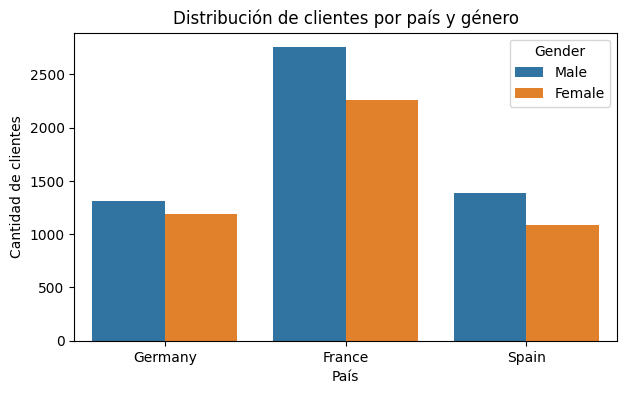

/tmp/ipython-input-2486082790.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set2')


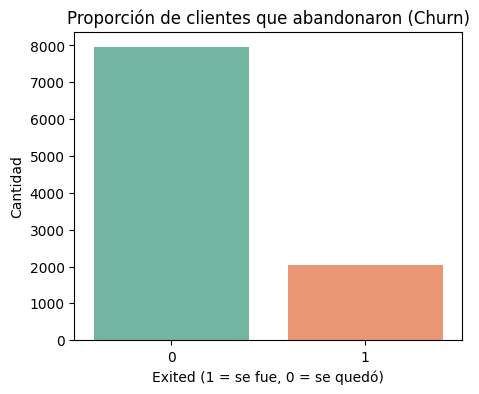

Tasa general de rotación de clientes: 20.38%


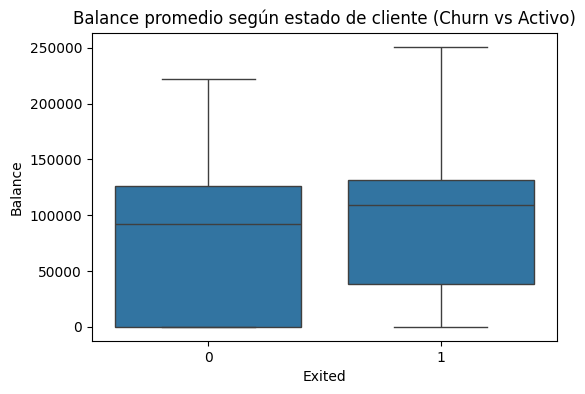

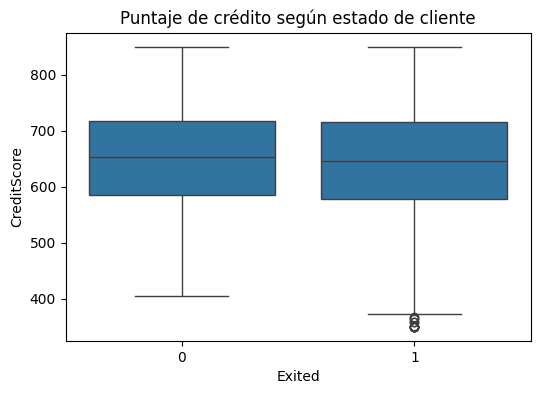

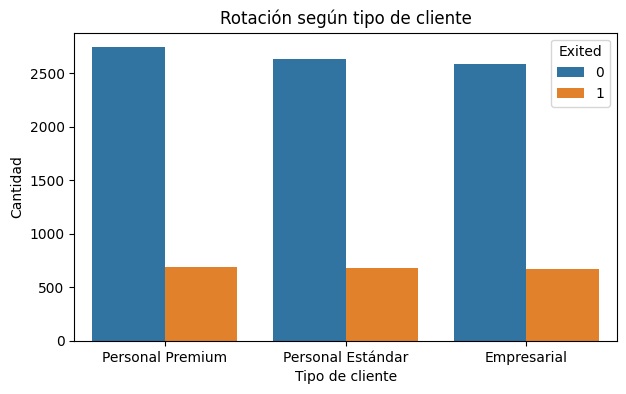

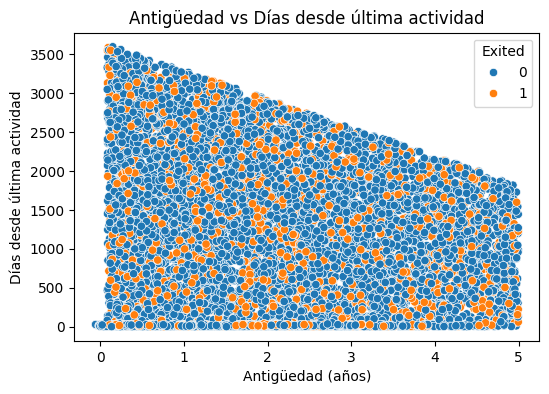

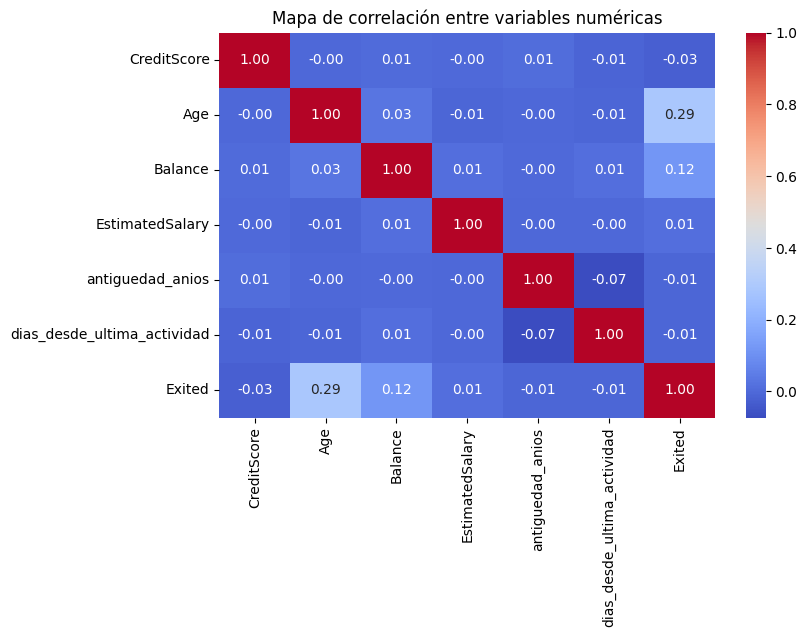

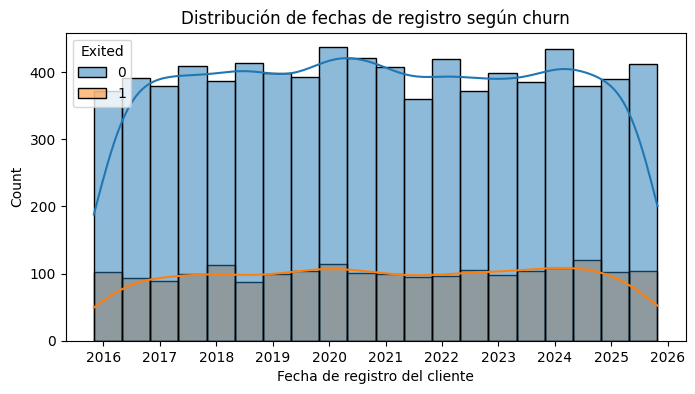

In [ ]:
# ANÁLISIS DESCRIPTIVO Y DIAGNÓSTICO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

# Conexión a BigQuery
key_path = "/content/nck-bank-351731acbfb0.json"
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

# Cargar los datos desde BigQuery
query = "SELECT * FROM `nck-bank.Cliente_Transaccion.TablaFinal`"
df = client.query(query).to_dataframe()

print("Datos cargados correctamente:", df.shape)
display(df.head())


# Análisis descriptivo general

print("\nResumen general de los datos:\n")
display(df.describe(include='all'))

print("\nMedidas de tendencia central y dispersión:")
metrics = df[['Age', 'CreditScore', 'Balance', 'EstimatedSalary']].agg(['mean','median','std','min','max'])
display(metrics)


# Distribuciones básicas

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Geography', hue='Gender')
plt.title("Distribución de clientes por país y género")
plt.xlabel("País")
plt.ylabel("Cantidad de clientes")
plt.show()

# Clientes que abandonaron
plt.figure(figsize=(5,4))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title("Proporción de clientes que abandonaron (Churn)")
plt.xlabel("Exited (1 = se fue, 0 = se quedó)")
plt.ylabel("Cantidad")
plt.show()

# Tasa general de churn
tasa_churn = (df['Exited'].mean() * 100).round(2)
print(f"Tasa general de rotación de clientes: {tasa_churn}%")


# Relación entre variables financieras y churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance promedio según estado de cliente (Churn vs Activo)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.title("Puntaje de crédito según estado de cliente")
plt.show()

# Análisis por tipo de cliente
plt.figure(figsize=(7,4))
sns.countplot(x='tipo_cliente', hue='Exited', data=df)
plt.title("Rotación según tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Cantidad")
plt.show()

# Análisis de fechas y actividad del cliente
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], errors='coerce')
df['fecha_ultima_actividad'] = pd.to_datetime(df['fecha_ultima_actividad'], errors='coerce')

# Calcular antigüedad
df['antiguedad_anios'] = (df['fecha_ultima_actividad'] - df['fecha_registro']).dt.days / 365

# Calcular días desde la última actividad
df['dias_desde_ultima_actividad'] = (pd.Timestamp.now() - df['fecha_ultima_actividad']).dt.days

# Relación entre antigüedad y actividad
plt.figure(figsize=(6,4))
sns.scatterplot(x='antiguedad_anios', y='dias_desde_ultima_actividad', hue='Exited', data=df)
plt.title("Antigüedad vs Días desde última actividad")
plt.xlabel("Antigüedad (años)")
plt.ylabel("Días desde última actividad")
plt.show()


# Correlaciones numéricas
corr = df[['CreditScore','Age','Balance','EstimatedSalary','antiguedad_anios','dias_desde_ultima_actividad','Exited']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de correlación entre variables numéricas")
plt.show()

# Diagnóstico adicional: Churn según tiempo de registro
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='fecha_registro', hue='Exited', bins=20, kde=True)
plt.title("Distribución de fechas de registro según churn")
plt.xlabel("Fecha de registro del cliente")
plt.show()


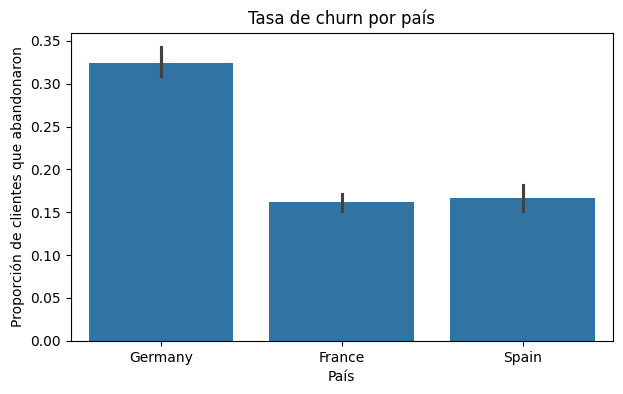

In [ ]:
# --- Churn por país ---
plt.figure(figsize=(7,4))
sns.barplot(x='Geography', y='Exited', data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Tasa de churn por país")
plt.xlabel("País")
plt.ylabel("Proporción de clientes que abandonaron")
plt.show()

Dataset cargado: 10000 registros, 21 columnas

Distribución de la variable objetivo (Exited):
Exited
0    7962
1    2038
Name: count, dtype: Int64

Tasa de Churn: 20.38%

********************************************************************************
INGENIERÍA DE CARACTERÍSTICAS

Nuevas características creadas:
antiguedad_dias: Días desde el registro
dias_inactivo: Días desde última actividad
balance_por_producto: Balance/número de productos
engagement_score: Score de compromiso con el banco

********************************************************************************
PREPROCESAMIENTO DE DATOS

Dimensiones finales:
Features (X): (10000, 15)
Target (y): (10000,)

Features utilizadas: 15 variables

********************************************************************************
DIVISIÓN DE DATOS

Conjunto de Entrenamiento: 7500 registros (75.0%)
Conjunto de Prueba: 2500 registros (25.0%)

Distribución en Train: Churn=20.39%
Distribución en Test: Churn=20.36%

✓ Escalado de features

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:58:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Entrenamiento de modelos base completado

********************************************************************************
EVALUACIÓN DE MODELOS - MÉTRICAS DE DESEMPEÑO

  LOGISTIC REGRESSION
  Accuracy:  0.8020  (80.20%)
  Precision: 0.5412  (De los predichos como churn, 54.1% realmente abandonaron)
  Recall:    0.1807  (Detectamos 18.1% de los clientes que abandonan)
  F1-Score:  0.2710  (Balance entre Precision y Recall)
  AUC-ROC:   0.7755  (Capacidad de discriminación del modelo)

  RANDOM FOREST
  Accuracy:  0.8560  (85.60%)
  Precision: 0.7525  (De los predichos como churn, 75.3% realmente abandonaron)
  Recall:    0.4361  (Detectamos 43.6% de los clientes que abandonan)
  F1-Score:  0.5522  (Balance entre Precision y Recall)
  AUC-ROC:   0.8518  (Capacidad de discriminación del modelo)

  XGBOOST
  Accuracy:  0.8488  (84.88%)
  Precision: 0.6866  (De los predichos como churn, 68.7% realmente abandonaron)
  Recall:    0.4735  (Detectamos 47.3% de los clientes que abandonan)
  F

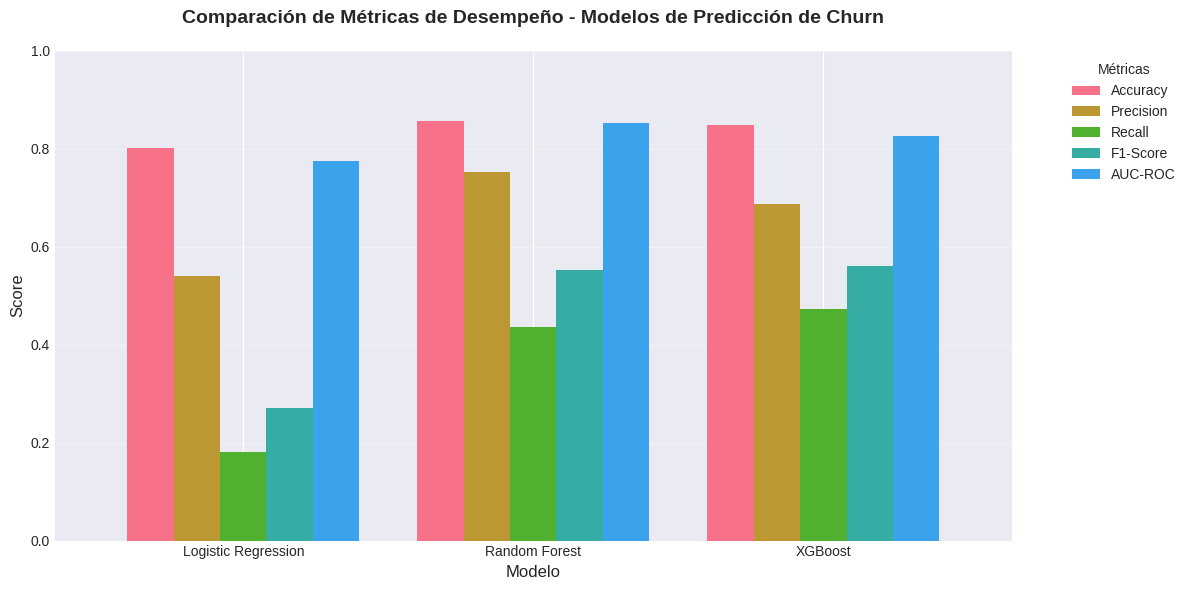

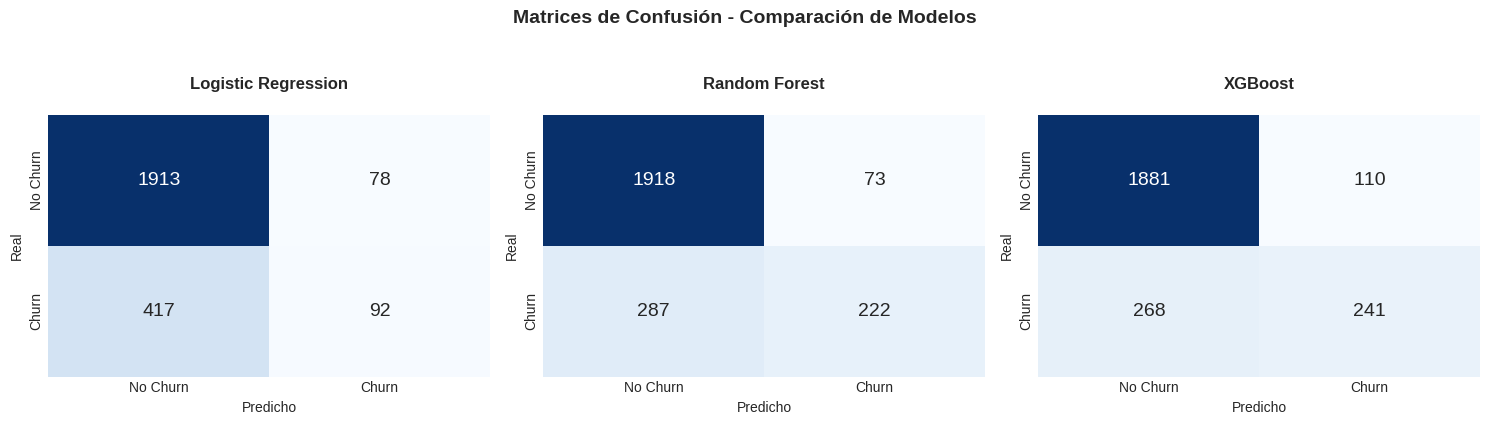

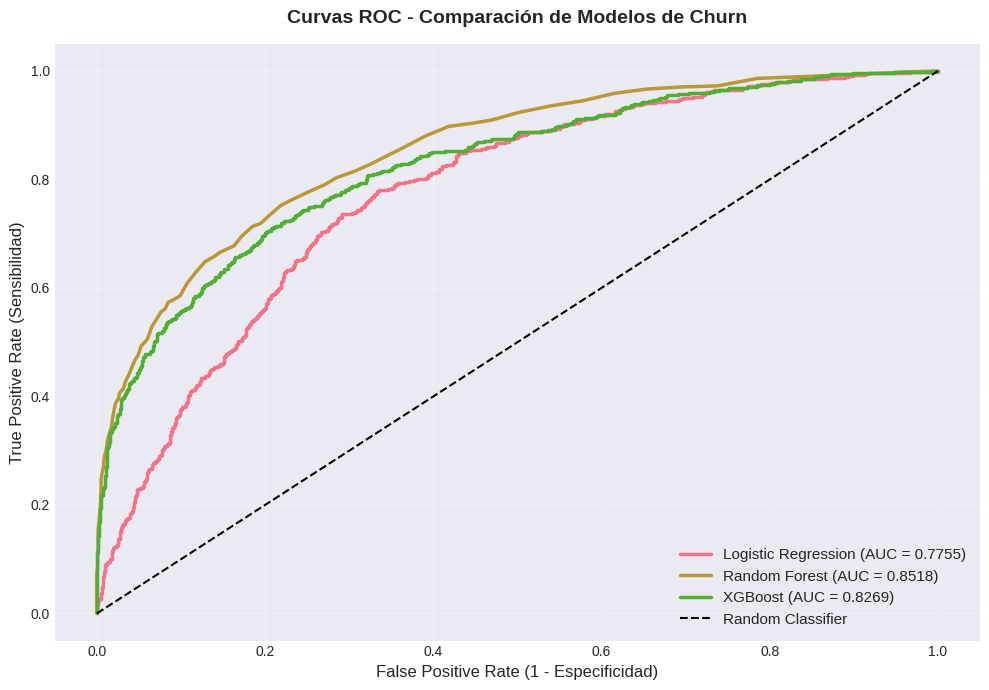

Visualizaciones generadas correctamente

********************************************************************************
FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS

Optimizando el mejor modelo: XGBoost

Configurando GridSearch para XGBoost...
Iniciando búsqueda de hiperparámetros (esto puede tardar varios minutos)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:06:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Optimización completada

Mejores hiperparámetros encontrados:
   - colsample_bytree: 0.9
   - learning_rate: 0.2
   - max_depth: 3
   - n_estimators: 100
   - subsample: 0.8

********************************************************************************
COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO
  Métrica  Modelo Base  Modelo Optimizado  Mejora (%)
 Accuracy     0.848800           0.853600    0.565504
Precision     0.686610           0.707246    3.005593
   Recall     0.473477           0.479371    1.244813
 F1-Score     0.560465           0.571429    1.956135
  AUC-ROC     0.826855           0.857072    3.654390

MEJORA PROMEDIO: 2.09%

********************************************************************************
IMPORTANCIA DE CARACTERÍSTICAS


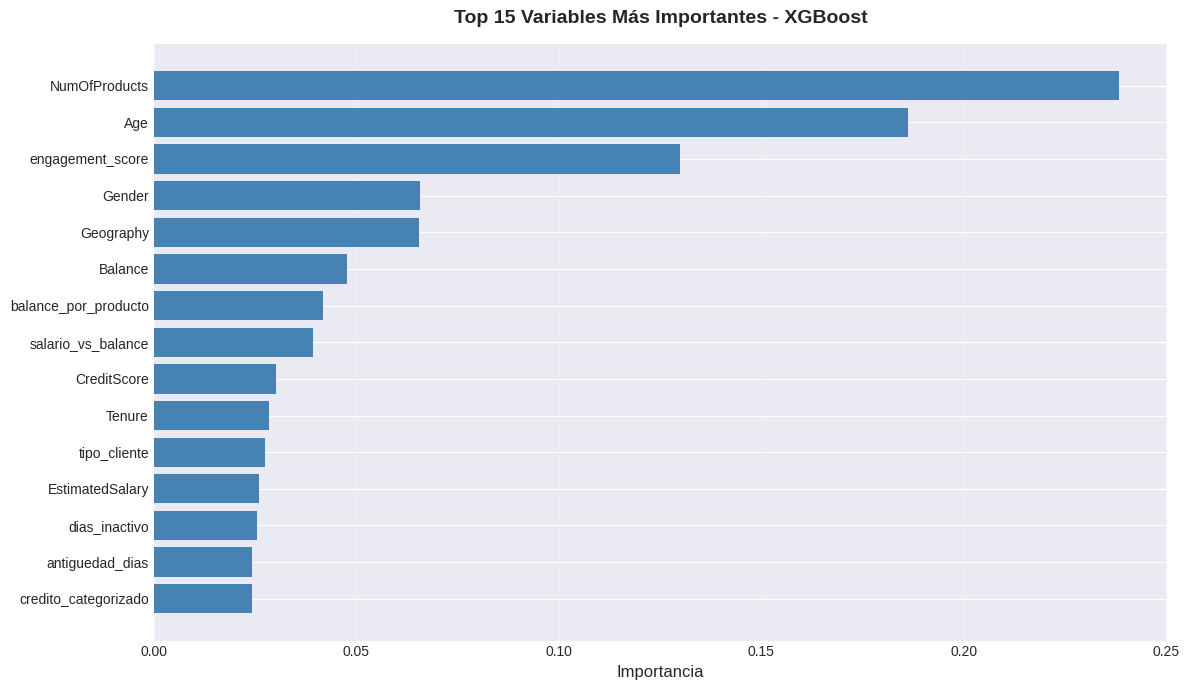


Top 10 variables más influyentes en la predicción de churn:
  1. NumOfProducts: 0.2383
  2. Age: 0.1862
  3. engagement_score: 0.1300
  4. Gender: 0.0657
  5. Geography: 0.0655
  6. Balance: 0.0477
  7. balance_por_producto: 0.0417
  8. salario_vs_balance: 0.0393
  9. CreditScore: 0.0301
  10. Tenure: 0.0284


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from google.cloud import bigquery
from google.oauth2 import service_account

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# CARGA Y PREPARACIÓN DE DATOS
# Conexión a BigQuery
key_path = "/content/nck-bank-351731acbfb0.json"
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

# Cargar datos
query = "SELECT * FROM `nck-bank.Cliente_Transaccion.TablaFinal`"
df = client.query(query).to_dataframe()

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo (Exited):")
print(df['Exited'].value_counts())
print(f"\nTasa de Churn: {(df['Exited'].mean()*100):.2f}%")


#INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
print("\n" + "*"*80)
print("INGENIERÍA DE CARACTERÍSTICAS")

# Convertir fechas
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], errors='coerce')
df['fecha_ultima_actividad'] = pd.to_datetime(df['fecha_ultima_actividad'], errors='coerce')

# Features temporales
df['antiguedad_dias'] = (df['fecha_ultima_actividad'] - df['fecha_registro']).dt.days
df['dias_inactivo'] = (pd.Timestamp.now() - df['fecha_ultima_actividad']).dt.days

# Features financieras
df['balance_por_producto'] = df['Balance'] / (df['NumOfProducts'] + 1)
df['salario_vs_balance'] = df['EstimatedSalary'] / (df['Balance'] + 1)
df['credito_categorizado'] = pd.cut(df['CreditScore'], bins=[0, 600, 700, 850], labels=['Bajo', 'Medio', 'Alto'])

# Features de engagement
df['tiene_tarjeta'] = df['HasCrCard'].astype(int)
df['es_miembro_activo'] = df['IsActiveMember'].astype(int)
df['engagement_score'] = df['tiene_tarjeta'] + df['es_miembro_activo'] + (df['NumOfProducts'] > 1).astype(int)

print("\nNuevas características creadas:")
print("antiguedad_dias: Días desde el registro")
print("dias_inactivo: Días desde última actividad")
print("balance_por_producto: Balance/número de productos")
print("engagement_score: Score de compromiso con el banco")


# PREPROCESAMIENTO PARA MODELOS
print("\n" + "*"*80)
print("PREPROCESAMIENTO DE DATOS")

features_numericas = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'antiguedad_dias', 'dias_inactivo',
    'balance_por_producto', 'salario_vs_balance', 'engagement_score'
]

features_categoricas = ['Geography', 'Gender', 'tipo_cliente', 'credito_categorizado']

# Crear dataset para modelado
X = df[features_numericas + features_categoricas].copy()
y = df['Exited'].copy()

# Encoding de variables categóricas
label_encoders = {}
for col in features_categoricas:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Manejar valores nulos
X.fillna(X.median(), inplace=True)

print(f"\nDimensiones finales:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeatures utilizadas: {len(X.columns)} variables")


# DIVISIÓN DE DATOS (TRAIN/TEST)
print("\n" + "*"*80)
print("DIVISIÓN DE DATOS")

# División estratificada mantiene proporción de churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"\nConjunto de Entrenamiento: {X_train.shape[0]} registros ({(len(X_train)/len(X)*100):.1f}%)")
print(f"Conjunto de Prueba: {X_test.shape[0]} registros ({(len(X_test)/len(X)*100):.1f}%)")
print(f"\nDistribución en Train: Churn={y_train.mean()*100:.2f}%")
print(f"Distribución en Test: Churn={y_test.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_numericas] = scaler.fit_transform(X_train[features_numericas])
X_test_scaled[features_numericas] = scaler.transform(X_test[features_numericas])

print("\n✓ Escalado de features numéricas completado(StandardScaler)")

# ENTRENAMIENTO DE MODELOS BASE (SIN OPTIMIZACIÓN)
print("\n" + "*"*80)
print("FASE 1: ENTRENAMIENTO DE MODELOS BASE")

# Diccionario para almacenar resultados
resultados = {}

# REGRESIÓN LOGÍSTICA
print("\nEntrenando Regresión Logística...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

resultados['Logistic Regression'] = {
    'model': lr_model,
    'y_pred': y_pred_lr,
    'y_proba': y_proba_lr
}

# MODELO 2: RANDOM FOREST
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

resultados['Random Forest'] = {
    'model': rf_model,
    'y_pred': y_pred_rf,
    'y_proba': y_proba_rf
}

# MODELO 3: XGBOOST
print("Entrenando XGBoost...")
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

resultados['XGBoost'] = {
    'model': xgb_model,
    'y_pred': y_pred_xgb,
    'y_proba': y_proba_xgb
}

print("\nEntrenamiento de modelos base completado")

# EVALUACIÓN DE MODELOS (MÉTRICAS DE DESEMPEÑO)

print("\n" + "*"*80)
print("EVALUACIÓN DE MODELOS - MÉTRICAS DE DESEMPEÑO")

metricas_df = []

for nombre, data in resultados.items():
    y_pred = data['y_pred']
    y_proba = data['y_proba']

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    metricas_df.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f"\n{'='*50}")
    print(f"  {nombre.upper()}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}  (De los predichos como churn, {prec*100:.1f}% realmente abandonaron)")
    print(f"  Recall:    {rec:.4f}  (Detectamos {rec*100:.1f}% de los clientes que abandonan)")
    print(f"  F1-Score:  {f1:.4f}  (Balance entre Precision y Recall)")
    print(f"  AUC-ROC:   {auc:.4f}  (Capacidad de discriminación del modelo)")

# DataFrame comparativo
df_metricas = pd.DataFrame(metricas_df)
print("\n" + "*"*80)
print("TABLA COMPARATIVA DE MÉTRICAS")

print(df_metricas.to_string(index=False))

# Identificar mejor modelo
mejor_modelo = df_metricas.loc[df_metricas['F1-Score'].idxmax(), 'Modelo']
print(f"\nMEJOR MODELO (por F1-Score): {mejor_modelo}")

# VISUALIZACIÓN DE RESULTADOS
print("\n" + "*"*80)
print("GENERANDO VISUALIZACIONES")


# GRÁFICO 1: Comparación de métricas
fig, ax = plt.subplots(figsize=(12, 6))
df_metricas_plot = df_metricas.set_index('Modelo')
df_metricas_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparación de Métricas de Desempeño - Modelos de Predicción de Churn',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Modelo', fontsize=12)
ax.legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# GRÁFICO 2: Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (nombre, data) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(f'{nombre}\n', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=10)
    axes[idx].set_xlabel('Predicho', fontsize=10)
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'])

plt.suptitle('Matrices de Confusión - Comparación de Modelos',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# GRÁFICO 3: Curvas ROC
fig, ax = plt.subplots(figsize=(10, 7))
for nombre, data in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_proba'])
    auc = roc_auc_score(y_test, data['y_proba'])
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})', linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax.set_xlabel('False Positive Rate (1 - Especificidad)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC - Comparación de Modelos de Churn',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualizaciones generadas correctamente")

# OPTIMIZACIÓN DE HIPERPARÁMETROS MODELO GANADOR

print("\n" + "*"*80)
print("FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS")
print(f"\nOptimizando el mejor modelo: {mejor_modelo}")

if mejor_modelo == 'Random Forest':
    print("\nConfigurando GridSearch para Random Forest...")

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("Iniciando búsqueda de hiperparámetros (esto puede tardar varios minutos)...")
    grid_search.fit(X_train, y_train)

    mejor_modelo_optimizado = grid_search.best_estimator_

elif mejor_modelo == 'XGBoost':
    print("\nConfigurando GridSearch para XGBoost...")

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }

    grid_search = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("Iniciando búsqueda de hiperparámetros (esto puede tardar varios minutos)...")
    grid_search.fit(X_train, y_train)

    mejor_modelo_optimizado = grid_search.best_estimator_

else:
    print("\nConfigurando GridSearch para Regresión Logística...")

    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }

    grid_search = GridSearchCV(
        LogisticRegression(random_state=42, max_iter=1000),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("Iniciando búsqueda de hiperparámetros...")
    grid_search.fit(X_train_scaled, y_train)

    mejor_modelo_optimizado = grid_search.best_estimator_

print("\nOptimización completada")
print(f"\nMejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

# Evaluar modelo optimizado
if mejor_modelo == 'Logistic Regression':
    y_pred_opt = mejor_modelo_optimizado.predict(X_test_scaled)
    y_proba_opt = mejor_modelo_optimizado.predict_proba(X_test_scaled)[:, 1]
else:
    y_pred_opt = mejor_modelo_optimizado.predict(X_test)
    y_proba_opt = mejor_modelo_optimizado.predict_proba(X_test)[:, 1]

# Métricas del modelo optimizado
print("\n" + "*"*80)
print("COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO")

# Métricas base
idx_mejor = df_metricas[df_metricas['Modelo'] == mejor_modelo].index[0]
metricas_base = df_metricas.loc[idx_mejor]

# Métricas optimizadas
acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_opt)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Modelo Base': [
        metricas_base['Accuracy'],
        metricas_base['Precision'],
        metricas_base['Recall'],
        metricas_base['F1-Score'],
        metricas_base['AUC-ROC']
    ],
    'Modelo Optimizado': [acc_opt, prec_opt, rec_opt, f1_opt, auc_opt],
    'Mejora (%)': [
        ((acc_opt - metricas_base['Accuracy']) / metricas_base['Accuracy'] * 100),
        ((prec_opt - metricas_base['Precision']) / metricas_base['Precision'] * 100),
        ((rec_opt - metricas_base['Recall']) / metricas_base['Recall'] * 100),
        ((f1_opt - metricas_base['F1-Score']) / metricas_base['F1-Score'] * 100),
        ((auc_opt - metricas_base['AUC-ROC']) / metricas_base['AUC-ROC'] * 100)
    ]
})

print(comparacion.to_string(index=False))

print(f"\nMEJORA PROMEDIO: {comparacion['Mejora (%)'].mean():.2f}%")

# IMPORTANCIA DE CARACTERÍSTICAS

if mejor_modelo in ['Random Forest', 'XGBoost']:
    print("\n" + "*"*80)
    print("IMPORTANCIA DE CARACTERÍSTICAS")

    importancias = mejor_modelo_optimizado.feature_importances_
    indices = np.argsort(importancias)[::-1][:15]

    plt.figure(figsize=(12, 7))
    plt.barh(range(len(indices)), importancias[indices], color='steelblue')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.xlabel('Importancia', fontsize=12)
    plt.title(f'Top 15 Variables Más Importantes - {mejor_modelo}',
              fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 variables más influyentes en la predicción de churn:")
    for i in range(min(10, len(indices))):
        print(f"  {i+1}. {X.columns[indices[i]]}: {importancias[indices[i]]:.4f}")


********************************************************************************
EXPORTACIÓN DE RESULTADOS

Top 20 clientes en mayor riesgo de churn:
 customer_id  churn_real  churn_predicho  probabilidad_churn riesgo_categoria
    15679770           1               1            0.995480             Alto
    15696989           1               1            0.995018             Alto
    15599329           1               1            0.994828             Alto
    15775318           1               1            0.994476             Alto
    15719508           1               1            0.994358             Alto
    15656148           1               1            0.992290             Alto
    15808674           1               1            0.991665             Alto
    15625761           1               1            0.989786             Alto
    15654562           1               1            0.988160             Alto
    15639357           1               1            0.987057         

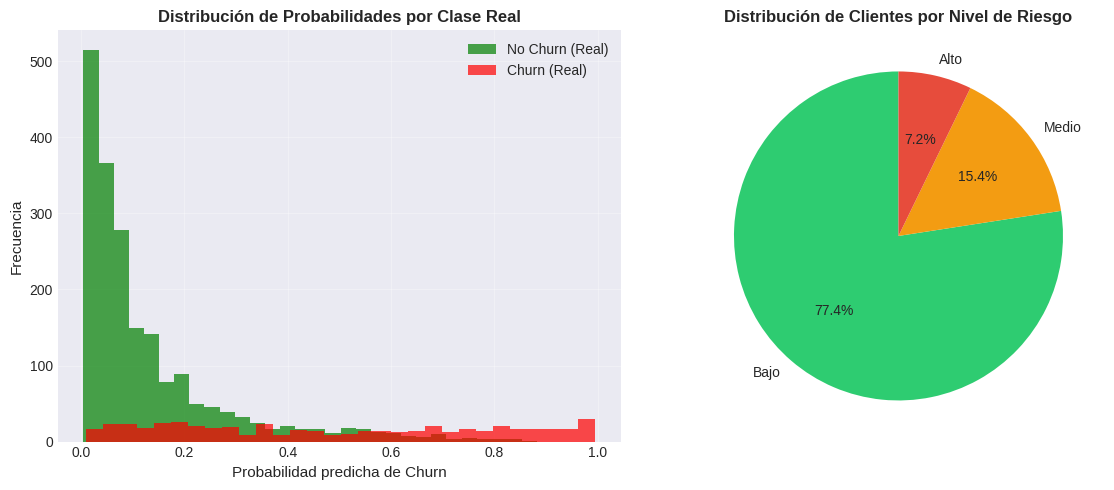


********************************************************************************
ANÁLISIS PREDICTIVO COMPLETADO EXITOSAMENTE

Modelos entrenados: 3 (Logistic Regression, Random Forest, XGBoost)
Mejor modelo: XGBoost
F1-Score optimizado: 0.5714
AUC-ROC: 0.8571
Mejora vs baseline: 2.09%
Clientes evaluados: 2500
Predicciones generadas: 2500


In [ ]:
# EXPORTAR RESULTADOS
print("\n" + "*"*80)
print("EXPORTACIÓN DE RESULTADOS")

# Crear predicciones finales con probabilidades
df_predicciones = pd.DataFrame({
    'customer_id': df.loc[X_test.index, 'customer_id'],
    'churn_real': y_test,
    'churn_predicho': y_pred_opt,
    'probabilidad_churn': y_proba_opt,
    'riesgo_categoria': pd.cut(
        y_proba_opt,
        bins=[0, 0.3, 0.7, 1.0],
        labels=['Bajo', 'Medio', 'Alto']
    )
})

# Ordenar por mayor riesgo
df_predicciones_sorted = df_predicciones.sort_values('probabilidad_churn', ascending=False)

print("\nTop 20 clientes en mayor riesgo de churn:")
print(df_predicciones_sorted.head(20).to_string(index=False))

# Guardar resultados
df_predicciones_sorted.to_csv('predicciones_churn_clientes.csv', index=False)
print("\n✓ Archivo 'predicciones_churn_clientes.csv' generado exitosamente")

# Estadísticas finales por categoría de riesgo
print("\nDistribución de clientes por nivel de riesgo:")
print(df_predicciones['riesgo_categoria'].value_counts().sort_index())

# Visualización final: Distribución de probabilidades
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_proba_opt[y_test == 0], bins=30, alpha=0.7, label='No Churn (Real)', color='green')
plt.hist(y_proba_opt[y_test == 1], bins=30, alpha=0.7, label='Churn (Real)', color='red')
plt.xlabel('Probabilidad predicha de Churn', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución de Probabilidades por Clase Real', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
risk_counts = df_predicciones['riesgo_categoria'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Distribución de Clientes por Nivel de Riesgo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "*"*80)
print("ANÁLISIS PREDICTIVO COMPLETADO EXITOSAMENTE")

print(f"""
Modelos entrenados: 3 (Logistic Regression, Random Forest, XGBoost)
Mejor modelo: {mejor_modelo}
F1-Score optimizado: {f1_opt:.4f}
AUC-ROC: {auc_opt:.4f}
Mejora vs baseline: {comparacion['Mejora (%)'].mean():.2f}%
Clientes evaluados: {len(y_test)}
Predicciones generadas: {len(df_predicciones)}""")

In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from google.oauth2 import service_account
from datetime import datetime
import pickle
from sklearn.preprocessing import LabelEncoder



# EXPORTAR MODELO Y CARGAR PREDICCIONES A BIGQUERY (BATCH)
print("*"*80)
print("CARGA BATCH DE PREDICCIONES A BIGQUERY")

# Configuración de conexión
key_path = "/content/nck-bank-351731acbfb0.json"
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

# Guardar modelo
with open('modelo_churn_optimizado.pkl', 'wb') as f:
    pickle.dump(mejor_modelo_optimizado, f)

# Guardar scaler
with open('scaler_churn.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar columnas utilizadas
feature_columns = X_train.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Modelo guardado: modelo_churn_optimizado.pkl")
print("Scaler guardado: scaler_churn.pkl")
print("Features guardadas: feature_columns.pkl")

# Generar predicciones para TODOS los clientes
print("\n" + "*"*80)
print("GENERANDO PREDICCIONES PARA TODOS LOS CLIENTES")

# Cargar datos completos desde BigQuery
query_completo = """
SELECT *
FROM `nck-bank.Cliente_Transaccion.TablaFinal`
WHERE Exited IS NOT NULL  -- Solo clientes activos
"""

df_completo = client.query(query_completo).to_dataframe()
print(f"\nClientes totales a predecir: {len(df_completo)}")
df_pred = df_completo.copy()

# Feature engineering
df_pred['fecha_registro'] = pd.to_datetime(df_pred['fecha_registro'], errors='coerce')
df_pred['fecha_ultima_actividad'] = pd.to_datetime(df_pred['fecha_ultima_actividad'], errors='coerce')

df_pred['antiguedad_dias'] = (df_pred['fecha_ultima_actividad'] - df_pred['fecha_registro']).dt.days
df_pred['dias_inactivo'] = (pd.Timestamp.now() - df_pred['fecha_ultima_actividad']).dt.days
df_pred['balance_por_producto'] = df_pred['Balance'] / (df_pred['NumOfProducts'] + 1)
df_pred['salario_vs_balance'] = df_pred['EstimatedSalary'] / (df_pred['Balance'] + 1)
df_pred['credito_categorizado'] = pd.cut(df_pred['CreditScore'],
                                          bins=[0, 600, 700, 850],
                                          labels=['Bajo', 'Medio', 'Alto'])
df_pred['tiene_tarjeta'] = df_pred['HasCrCard'].astype(int)
df_pred['es_miembro_activo'] = df_pred['IsActiveMember'].astype(int)
df_pred['engagement_score'] = (df_pred['tiene_tarjeta'] +
                                df_pred['es_miembro_activo'] +
                                (df_pred['NumOfProducts'] > 1).astype(int))

# Seleccionar features
features_numericas = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'antiguedad_dias', 'dias_inactivo',
    'balance_por_producto', 'salario_vs_balance', 'engagement_score'
]

features_categoricas = ['Geography', 'Gender', 'tipo_cliente', 'credito_categorizado']

X_pred = df_pred[features_numericas + features_categoricas].copy()

for col in features_categoricas:
    le = LabelEncoder()
    X_pred[col] = le.fit_transform(X_pred[col].astype(str))

X_pred.fillna(X_pred.median(), inplace=True)

# Realizar predicciones
print("\nGenerando predicciones")

# Cargar modelo guardado
with open('modelo_churn_optimizado.pkl', 'rb') as f:
    modelo_cargado = pickle.load(f)

# Predecir
y_pred_all = modelo_cargado.predict(X_pred)
y_proba_all = modelo_cargado.predict_proba(X_pred)[:, 1]

print("Predicciones generadas")


# Crear tabla de resultados para Power BI
print("\nCreando tabla de resultados")

df_resultados = pd.DataFrame({
    'customer_id': df_completo['customer_id'],
    'churn_predicho': y_pred_all.astype(int),
    'probabilidad_churn': y_proba_all.round(4),
    'riesgo_categoria': pd.cut(
        y_proba_all,
        bins=[0, 0.3, 0.7, 1.0],
        labels=['Bajo', 'Medio', 'Alto']
    ),
    'fecha_prediccion': datetime.now(),
    'modelo_version': '1.0'
})

# Añadir información adicional útil
df_resultados['es_alto_riesgo'] = (df_resultados['probabilidad_churn'] >= 0.7).astype(int)
df_resultados['requiere_atencion'] = (df_resultados['probabilidad_churn'] >= 0.5).astype(int)

# Añadir campos de negocio desde tabla original
df_resultados = df_resultados.merge(
    df_completo[['customer_id', 'Geography', 'Gender', 'Age', 'Balance',
                 'EstimatedSalary', 'tipo_cliente', 'NumOfProducts']],
    on='customer_id',
    how='left'
)

print(f"\nTabla de resultados creada: {df_resultados.shape}")
print("\nVista previa:")
print(df_resultados.head(10))


# Cargar a BigQuery
print("\n" + "*"*80)
print("CARGANDO PREDICCIONES A BIGQUERY")

dataset_id = "Cliente_Transaccion"
tabla_predicciones = "Predicciones_ChurnFinal"

# Configurar tabla con esquema explícito
table_id = f"{credentials.project_id}.{dataset_id}.{tabla_predicciones}"
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

# Cargar tabla
job = client.load_table_from_dataframe(
    df_resultados,
    table_id,
    job_config=job_config
)

job.result()

print(f"\nTabla '{tabla_predicciones}' creada/actualizada en BigQuery")
print(f"Registros cargados: {len(df_resultados)}")
print(f"Ruta completa: {table_id}")

# Verificar carga
query_verificacion = f"""
SELECT
    riesgo_categoria,
    COUNT(*) as cantidad,
    ROUND(AVG(probabilidad_churn), 4) as prob_promedio
FROM `{table_id}`
GROUP BY riesgo_categoria
ORDER BY riesgo_categoria
"""

resultado = client.query(query_verificacion).to_dataframe()
print("\nDistribución de riesgo en BigQuery:")
print(resultado)


# CREAR VISTA EN BIGQUERY CON JOINS AUTOMÁTICOS
print("\n" + "*"*80)
print("CREAR VISTA SQL PARA POWER BI")

vista_sql = f"""
CREATE OR REPLACE VIEW `{credentials.project_id}.{dataset_id}.Vista_Clientes_Con_PrediccionesFinal` AS

SELECT
    t.customer_id,
    t.Surname,
    t.CreditScore,
    t.Geography,
    t.Gender,
    t.Age,
    t.Tenure,
    t.Balance,
    t.NumOfProducts,
    t.HasCrCard,
    t.IsActiveMember,
    t.EstimatedSalary,
    t.Exited as churn_real,
    t.tipo_cliente,
    t.fecha_registro,
    t.fecha_ultima_actividad,

    -- Predicciones del modelo
    p.churn_predicho,
    p.probabilidad_churn,
    p.riesgo_categoria,
    p.es_alto_riesgo,
    p.requiere_atencion,
    p.fecha_prediccion,
    p.modelo_version,

    -- KPIs calculados
    DATE_DIFF(CURRENT_DATE(), DATE(t.fecha_registro), DAY) as dias_como_cliente,
    DATE_DIFF(CURRENT_DATE(), DATE(t.fecha_ultima_actividad), DAY) as dias_sin_actividad,

    -- Segmentación adicional
    CASE
        WHEN p.probabilidad_churn >= 0.7 AND t.Balance > 50000 THEN 'Crítico - Alto Valor'
        WHEN p.probabilidad_churn >= 0.7 THEN 'Crítico - Valor Estándar'
        WHEN p.probabilidad_churn >= 0.5 THEN 'Alerta Temprana'
        ELSE 'Estable'
    END as segmento_accion

FROM `{credentials.project_id}.{dataset_id}.TablaFinal` t
LEFT JOIN `{credentials.project_id}.{dataset_id}.{tabla_predicciones}` p
    ON t.customer_id = p.customer_id
"""

# Ejecutar creación de vista
client.query(vista_sql).result()
print("Vista 'Vista_Clientes_Con_PrediccionesFinal' creada exitosamente")

********************************************************************************
CARGA BATCH DE PREDICCIONES A BIGQUERY
Modelo guardado: modelo_churn_optimizado.pkl
Scaler guardado: scaler_churn.pkl
Features guardadas: feature_columns.pkl

********************************************************************************
GENERANDO PREDICCIONES PARA TODOS LOS CLIENTES

Clientes totales a predecir: 10000

Generando predicciones
Predicciones generadas

Creando tabla de resultados

Tabla de resultados creada: (10000, 15)

Vista previa:
   customer_id  churn_predicho  probabilidad_churn riesgo_categoria  \
0     15647091               0              0.1658             Bajo   
1     15713826               0              0.3509            Medio   
2     15633840               0              0.0351             Bajo   
3     15769915               0              0.0968             Bajo   
4     15652674               0              0.0425             Bajo   
5     15700864               0        